# Three-flavour neutrino oscillations: vacuum vs matter

This notebook uses the small `nuosc` package in this folder to compute
$P(\nu_\alpha\to\nu_\beta)$ for all nine channels

* in **vacuum**, with the textbook PMNS formula;
* in **constant-density matter**, with the **NuFast** algorithm
  (Denton & Parke, [arXiv:2405.02400](https://arxiv.org/abs/2405.02400)).

Default parameters are the NuFIT 6.0 best fit ([arXiv:2410.05380](https://arxiv.org/abs/2410.05380)).

**Units:** $E$ in GeV, $L$ in km, $\Delta m^2$ in eV$^2$, $\rho$ in g/cm$^3$, $\delta_{CP}$ in degrees.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import NeutrinoOscillator, EXPERIMENTS, get_experiment, FLAVOUR_LABELS

from nuosc.plotting import set_style
SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

def label(a, b, anti=False):
    # LaTeX label for P(nu_a -> nu_b); a, b can be 'e'/'mu'/'tau' or 0/1/2
    idx = {"e": 0, "mu": 1, "tau": 2}
    a, b = idx.get(a, a), idx.get(b, b)
    nu = r"\bar\nu" if anti else r"\nu"
    return rf"$P({nu}_{{{FLAVOUR_LABELS[a]}}}\to{nu}_{{{FLAVOUR_LABELS[b]}}})$"

def energy_axis(exp):
    # (scale, label) so that reactor energies are plotted in MeV, the rest in GeV
    if exp["E_peak"] < 0.1:
        return 1e3, r"$E_\nu$ [MeV]"
    return 1.0, r"$E_\nu$ [GeV]"

## 0. Configuration

All experiment setups (baseline, density, energy range, beam mode, main channel)
live in `nuosc/experiments.py`. **Change `EXPERIMENT` below and re-run the notebook**
to redo every single-experiment plot; `COMPARE` sets which experiments are shown
side by side. To add a new experiment, add an entry to `EXPERIMENTS` in that file.

*Hyper-Kamiokande* uses the same J-PARC beam, off-axis angle and baseline (295 km) as T2K, so its oscillation **probabilities are identical to T2K's** (the curves overlap); HK differs only in the number of events (187 kt vs 22.5 kt and a 1.3 MW beam), see `realistic_event_rates.ipynb` and `fd_spectra_quickstart.ipynb`.

In [ ]:
# ------------------------------------------------------------------ #
EXPERIMENT = "NOvA"                    # "T2K", "NOvA", "DUNE", "HyperK", "JUNO"
COMPARE    = ["T2K", "HyperK", "NOvA", "DUNE"]   # experiments compared side by side
N_ENERGY   = 2000                      # points in the energy grids
# ------------------------------------------------------------------ #

exp = get_experiment(EXPERIMENT)
alpha, beta = exp["channel"]
E_scale, E_label = energy_axis(exp)

print(f"{'':8s} {'L [km]':>7s} {'rho':>6s} {'E_peak [GeV]':>13s}  channel")
for name, cfg in EXPERIMENTS.items():
    mark = "->" if name == exp["name"] else "  "
    a, b = cfg["channel"]
    print(f"{mark}{name:6s} {cfg['baseline']:7.1f} {cfg['rho']:6.3f} {cfg['E_peak']:13.4g}  "
          f"{'anti-' if cfg['antineutrino'] else ''}{a} -> {b}")

          L [km]    rho  E_peak [GeV]  channel
  T2K      295.0  2.600           0.6  mu -> e
->NOvA     810.0  2.840             2  mu -> e
  DUNE    1300.0  2.848           2.5  mu -> e
  JUNO      52.5  2.450         0.004  anti-e -> e


## 1. Setting up an oscillator

`NeutrinoOscillator.from_experiment` takes baseline, density, energy grid and beam mode
from the configuration; the mass ordering and any oscillation parameter can be passed on top.

In [ ]:
osc = NeutrinoOscillator.from_experiment(EXPERIMENT, ordering="NO", n_energy=N_ENERGY)
print(osc)

NeutrinoOscillator(NO, neutrino, L = 810.0 km, rho = 2.84 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02215  (th13 = 8.56 deg)
  sin^2(th23) = 0.4700   (th23 = 43.28 deg)
  delta_CP    = 212.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = +2.5130e-03 eV^2
  dm2_32      = +2.4381e-03 eV^2


In [ ]:
# PMNS matrix and |U_ai|^2
np.set_printoptions(precision=3, suppress=True)
print("U =\n", osc.U)
print("\n|U|^2 =\n", np.abs(osc.U)**2)

U =
 [[ 0.823+0.j     0.549+0.j    -0.126+0.079j]
 [-0.332+0.045j  0.654+0.03j   0.678+0.j   ]
 [ 0.457+0.048j -0.519+0.032j  0.72 +0.j   ]]

|U|^2 =
 [[0.677 0.301 0.022]
 [0.112 0.428 0.46 ]
 [0.211 0.271 0.518]]


In [ ]:
# Everything can still be changed by hand:
osc.ordering = "IO"                    # reload NuFIT IO best fit
osc.set_params(delta_cp=270.0)         # change any parameter
osc.rho = 3.0                          # g/cm^3
print(osc)

osc = NeutrinoOscillator.from_experiment(EXPERIMENT, n_energy=N_ENERGY)   # back to default

NeutrinoOscillator(IO, neutrino, L = 810.0 km, rho = 3.0 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02231  (th13 = 8.59 deg)
  sin^2(th23) = 0.5500   (th23 = 47.87 deg)
  delta_CP    = 270.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = -2.4091e-03 eV^2
  dm2_32      = -2.4840e-03 eV^2


## 2. Main channel: vacuum vs matter, NO vs IO

For accelerator experiments, matter enhances $P(\nu_\mu\to\nu_e)$ for NO and
suppresses it for IO; for antineutrinos it is the other way around. The effect grows with
the baseline, which is why DUNE is more sensitive to the mass ordering than NOvA and T2K.

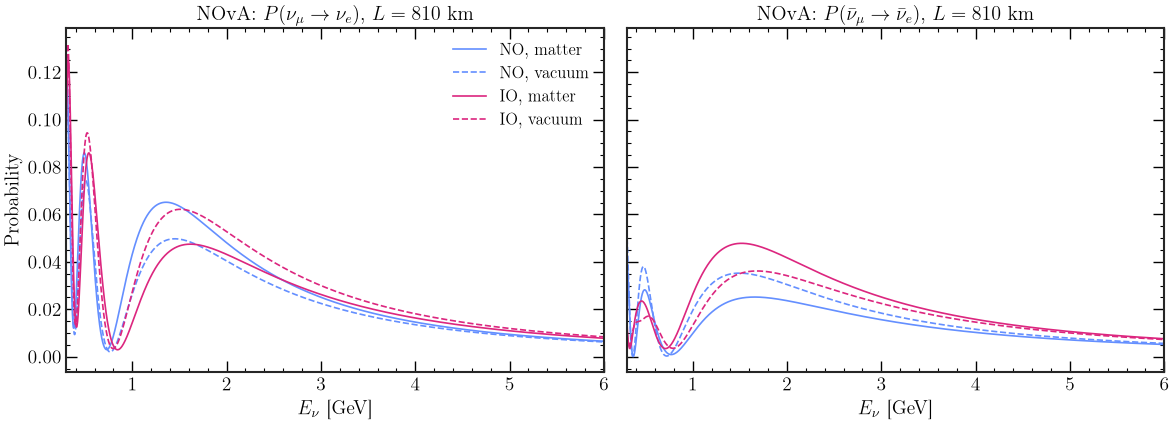

In [ ]:
E = osc.energy

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, anti in zip(axes, [False, True]):
    for i, ordering in enumerate(["NO", "IO"]):
        o = NeutrinoOscillator.from_experiment(EXPERIMENT, ordering=ordering,
                                               antineutrino=anti, n_energy=N_ENERGY)
        ax.plot(E * E_scale, o.matter(alpha, beta), color=c[i], label=f"{ordering}, matter")
        ax.plot(E * E_scale, o.vacuum(alpha, beta), color=c[i], ls="--", label=f"{ordering}, vacuum")
    ax.set_xlabel(E_label)
    ax.set_title(rf"{exp['name']}: " + label(alpha, beta, anti) + rf",  $L = {exp['baseline']:g}$ km")
    ax.set_xlim(E[0] * E_scale, E[-1] * E_scale)
axes[0].set_ylabel("Probability")
axes[0].legend()
plt.tight_layout()
plt.show()

### 2b. Comparing experiments

$P(\nu_\mu\to\nu_e)$ (top) and $P(\bar\nu_\mu\to\bar\nu_e)$ (bottom) for the experiments in `COMPARE`.
The dotted vertical line marks the flux-peak energy of each experiment.

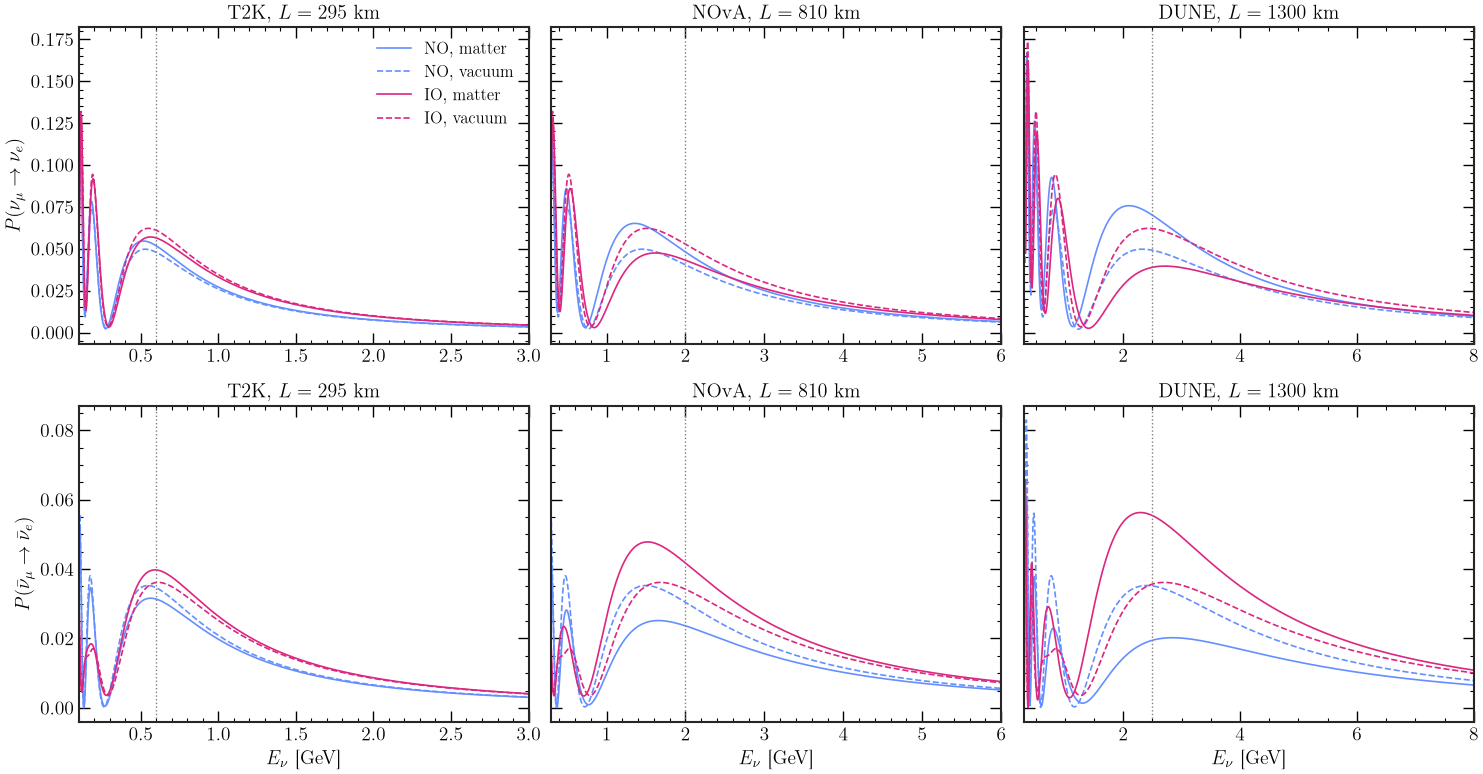

In [ ]:
fig, axes = plt.subplots(2, len(COMPARE), figsize=(5 * len(COMPARE), 8), sharey="row", squeeze=False)
for j, name in enumerate(COMPARE):
    cfg = get_experiment(name)
    a, b = cfg["channel"]
    for row, anti in enumerate([False, True]):
        ax = axes[row, j]
        for i, ordering in enumerate(["NO", "IO"]):
            o = NeutrinoOscillator.from_experiment(name, ordering=ordering,
                                                   antineutrino=anti, n_energy=N_ENERGY)
            ax.plot(o.energy, o.matter(a, b), color=c[i], label=f"{ordering}, matter")
            ax.plot(o.energy, o.vacuum(a, b), color=c[i], ls="--", label=f"{ordering}, vacuum")
        ax.axvline(cfg["E_peak"], color="grey", ls=":", lw=1)
        ax.set_xlim(*cfg["E_range"])
        ax.set_title(rf"{name}, $L = {cfg['baseline']:g}$ km")
        if j == 0:
            ax.set_ylabel(label(a, b, anti))
        if row == 1:
            ax.set_xlabel(r"$E_\nu$ [GeV]")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

## 3. All nine channels

Solid: matter (NuFast). Dashed: vacuum. Each row and each column of the
$3\times3$ matrix sums to one (unitarity).

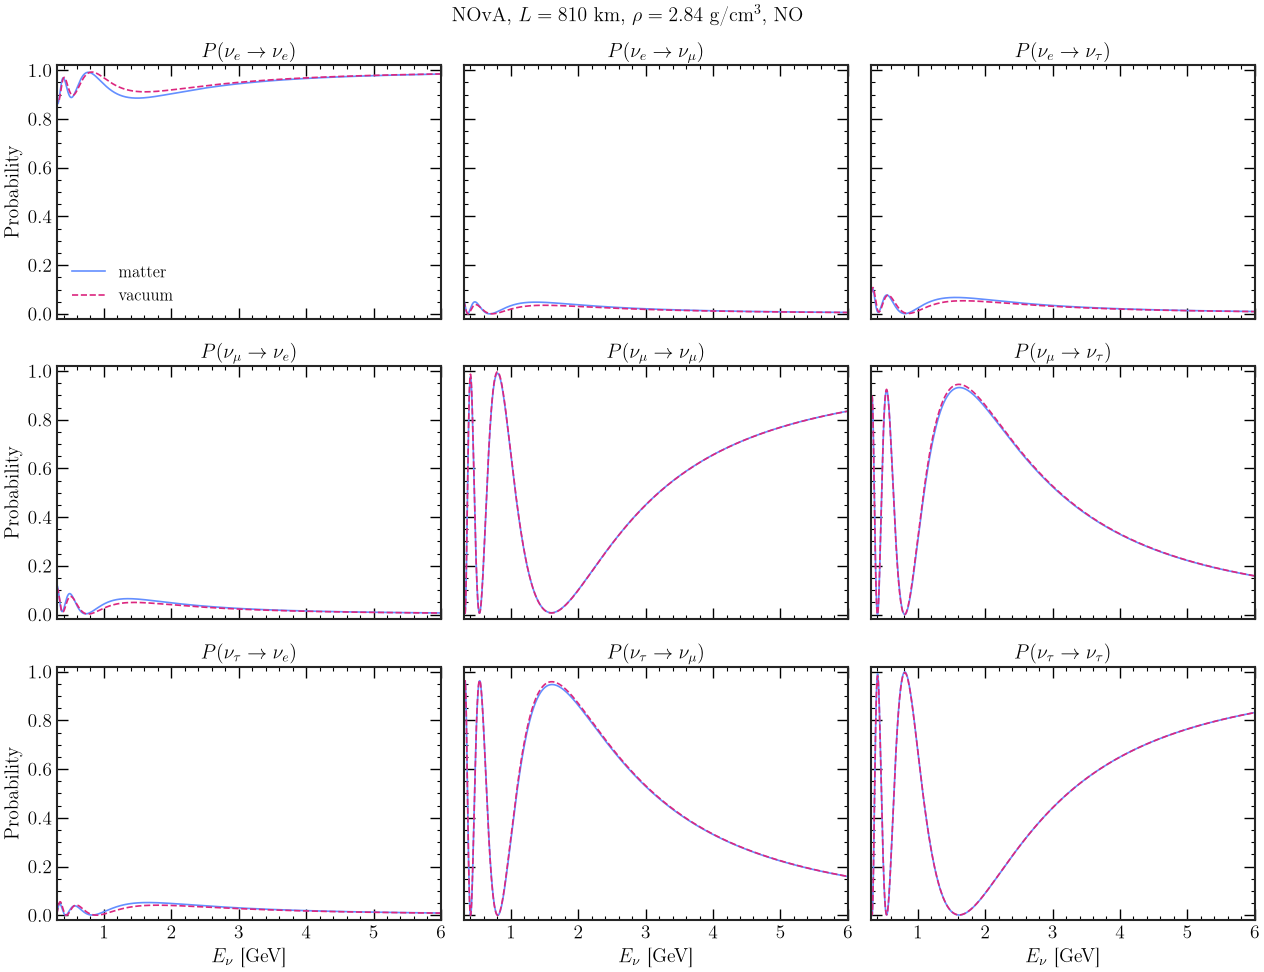

max |row sum - 1| = 2.220446049250313e-16
max |col sum - 1| = 1.1102230246251565e-16


In [ ]:
osc = NeutrinoOscillator.from_experiment(EXPERIMENT, n_energy=N_ENERGY)
E = osc.energy
P_mat = osc.matter()      # shape (3, 3, len(E))
P_vac = osc.vacuum()

fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
for a in range(3):
    for b in range(3):
        ax = axes[a, b]
        ax.plot(E * E_scale, P_mat[a, b], color=c[0], label="matter")
        ax.plot(E * E_scale, P_vac[a, b], color=c[1], ls="--", label="vacuum")
        ax.set_title(label(a, b, osc.antineutrino))
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlim(E[0] * E_scale, E[-1] * E_scale)
for ax in axes[-1]:
    ax.set_xlabel(E_label)
for ax in axes[:, 0]:
    ax.set_ylabel("Probability")
axes[0, 0].legend()
fig.suptitle(rf"{exp['name']}, $L = {exp['baseline']:g}$ km, $\rho = {exp['rho']}$ g/cm$^3$, NO")
plt.tight_layout()
plt.show()

print("max |row sum - 1| =", np.abs(P_mat.sum(axis=1) - 1).max())
print("max |col sum - 1| =", np.abs(P_mat.sum(axis=0) - 1).max())

### 3b. The $\nu_\mu$ channels as a function of $L/E$

In vacuum the probabilities depend on $L$ and $E$ only through $L/E$
($\Delta_{ij} = 1.267\,\Delta m^2_{ij} L/E$): plotting vs $L/E$, **all experiments fall on the same
curve**. Matter breaks this scaling, because the matter potential grows with $E$ and its effect
accumulates with $L$. Below: $P(\nu_\mu\to\nu_e)$, $P(\nu_\mu\to\nu_\mu)$ and $P(\nu_\mu\to\nu_\tau)$ vs $L/E$
for the experiments in `COMPARE` (each over its own energy range), in vacuum (top) and in matter
(bottom). The vertical lines mark the first and second oscillation maxima,
$L/E = (2n-1)\,\pi / (2\cdot 1.267\,\Delta m^2_{31})$.

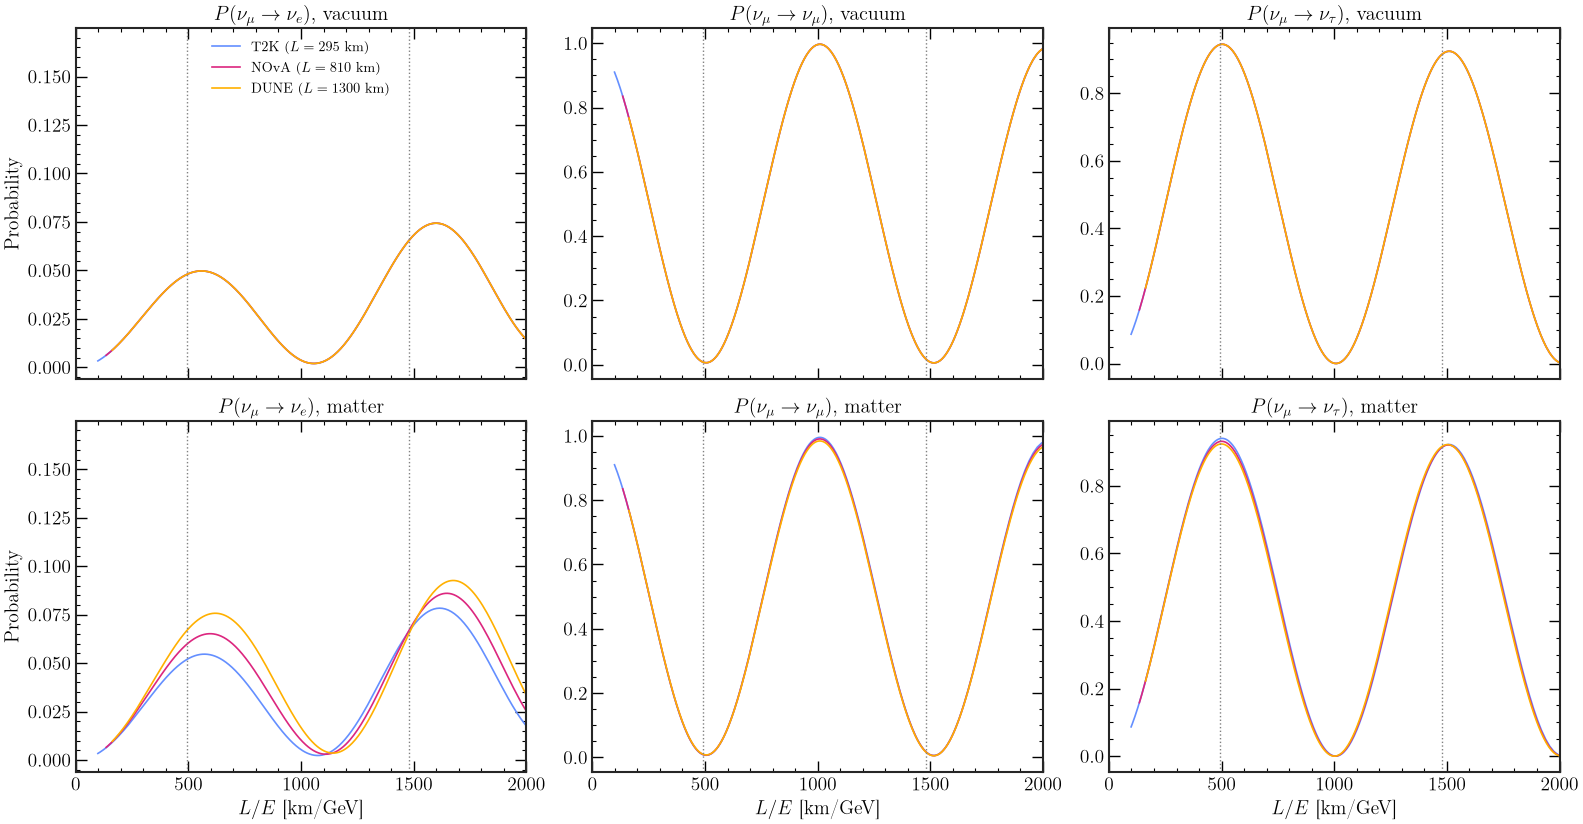

In [ ]:
from nuosc import K_PHASE

mu_channels = [("mu", "e"), ("mu", "mu"), ("mu", "tau")]
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharex=True, sharey="col")
dm2_31 = NeutrinoOscillator("NO").dm2_31
LE_max = [(2 * n - 1) * np.pi / (2 * K_PHASE * dm2_31) for n in (1, 2)]   # km/GeV
for j, name in enumerate(COMPARE):
    o = NeutrinoOscillator.from_experiment(name, ordering="NO", n_energy=N_ENERGY)
    LE = o.baseline / o.energy                                   # km / GeV
    for row, matter in enumerate([False, True]):
        P = o.probability(E=o.energy, matter=matter)
        for col, (a, b) in enumerate(mu_channels):
            axes[row, col].plot(LE, P[1, {"e": 0, "mu": 1, "tau": 2}[b]], color=c[j],
                                ls="--" if name == "HyperK" else "-",   # HK overlaps T2K (same L)
                                label=f"{name} ($L = {o.baseline:g}$ km)")
for col, (a, b) in enumerate(mu_channels):
    axes[0, col].set_title(label(a, b) + ", vacuum")
    axes[1, col].set_title(label(a, b) + ", matter")
    axes[1, col].set_xlabel(r"$L/E$ [km/GeV]")
    for ax in axes[:, col]:
        for x in LE_max:
            ax.axvline(x, color="grey", ls=":", lw=1)
axes[0, 0].set_xlim(0, 2000)
axes[0, 0].set_ylabel("Probability"); axes[1, 0].set_ylabel("Probability")
axes[0, 0].legend(fontsize="small")
plt.tight_layout()
plt.show()

In [ ]:
# Same plot for antineutrinos (nu_mu-bar channels)
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharex=True, sharey="col")
for j, name in enumerate(COMPARE):
    o = NeutrinoOscillator.from_experiment(name, ordering="NO", antineutrino=True, n_energy=N_ENERGY)
    LE = o.baseline / o.energy                                   # km / GeV
    for row, matter in enumerate([False, True]):
        P = o.probability(E=o.energy, matter=matter)
        for col, (a, b) in enumerate(mu_channels):
            axes[row, col].plot(LE, P[1, {"e": 0, "mu": 1, "tau": 2}[b]], color=c[j],
                                ls="--" if name == "HyperK" else "-",   # HK overlaps T2K (same L)
                                label=f"{name} ($L = {o.baseline:g}$ km)")
for col, (a, b) in enumerate(mu_channels):
    axes[0, col].set_title(label(a, b, anti=True) + ", vacuum")
    axes[1, col].set_title(label(a, b, anti=True) + ", matter")
    axes[1, col].set_xlabel(r"$L/E$ [km/GeV]")
    for ax in axes[:, col]:
        for x in LE_max:
            ax.axvline(x, color="grey", ls=":", lw=1)
axes[0, 0].set_xlim(0, 2000)
axes[0, 0].set_ylabel("Probability"); axes[1, 0].set_ylabel("Probability")
axes[0, 0].legend(fontsize="small")
plt.tight_layout()
plt.show()

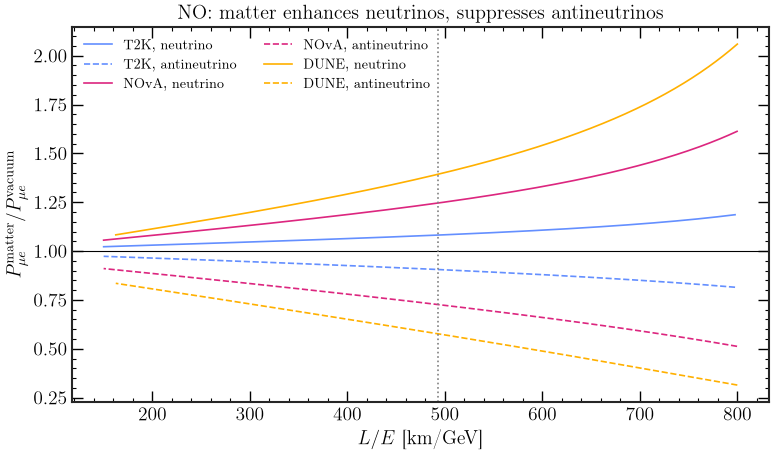

In [ ]:
# Ratio matter / vacuum vs L/E: where (and for which experiment) matter effects matter
fig, ax = plt.subplots(figsize=(8, 4.8))
for j, name in enumerate(COMPARE):
    for i, anti in enumerate([False, True]):
        o = NeutrinoOscillator.from_experiment(name, ordering="NO", antineutrino=anti, n_energy=N_ENERGY)
        LE = o.baseline / o.energy
        r = o.matter("mu", "e") / o.vacuum("mu", "e")
        m = (LE > 150) & (LE < 800)           # around the first maximum (avoid the P ~ 0 region)
        ax.plot(LE[m], r[m], color=c[j], ls="-" if not anti else "--",
                label=f"{name}, {'antineutrino' if anti else 'neutrino'}")
ax.axhline(1, color="k", lw=0.8)
ax.axvline(LE_max[0], color="grey", ls=":")
ax.set_xlabel(r"$L/E$ [km/GeV]")
ax.set_ylabel(r"$P_{\mu e}^\mathrm{matter} / P_{\mu e}^\mathrm{vacuum}$")
ax.set_title("NO: matter enhances neutrinos, suppresses antineutrinos")
ax.legend(fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

## 4. CP violation

### 4a. Main channel for different values of $\delta_{CP}$

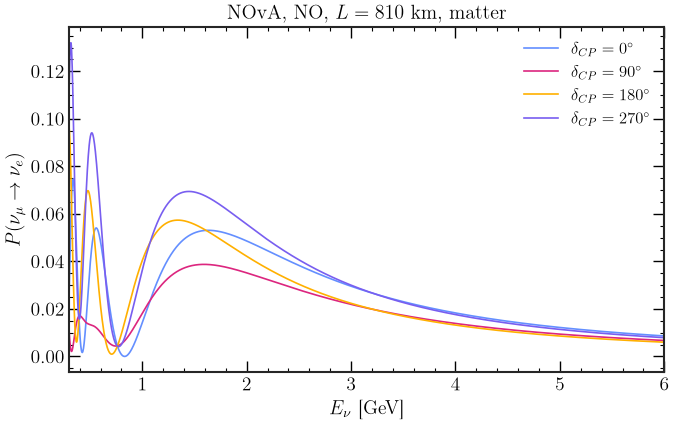

In [ ]:
osc = NeutrinoOscillator.from_experiment(EXPERIMENT, n_energy=N_ENERGY)
E = osc.energy

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, d in enumerate([0, 90, 180, 270]):
    osc.set_params(delta_cp=d)
    ax.plot(E * E_scale, osc.matter(alpha, beta), color=c[i], label=rf"$\delta_{{CP}} = {d}^\circ$")
ax.set_xlabel(E_label)
ax.set_ylabel(label(alpha, beta, osc.antineutrino))
ax.set_title(rf"{exp['name']}, NO, $L = {exp['baseline']:g}$ km, matter")
ax.set_xlim(E[0] * E_scale, E[-1] * E_scale)
ax.legend()
plt.tight_layout()
plt.show()

### 4b. Bi-probability plot

Varying $\delta_{CP}$ from $0$ to $2\pi$ at the peak energy of each experiment traces an ellipse
in the $\left(P(\nu_\mu\to\nu_e),\,P(\bar\nu_\mu\to\bar\nu_e)\right)$ plane.
Dashed lines are vacuum: there NO and IO differ only because NuFIT prefers different
values of $\theta_{23}$. Solid lines include matter, which pulls the two orderings apart,
more and more going from T2K to NOvA to DUNE. Circles mark $\delta_{CP}=0$, squares $\delta_{CP}=90^\circ$.

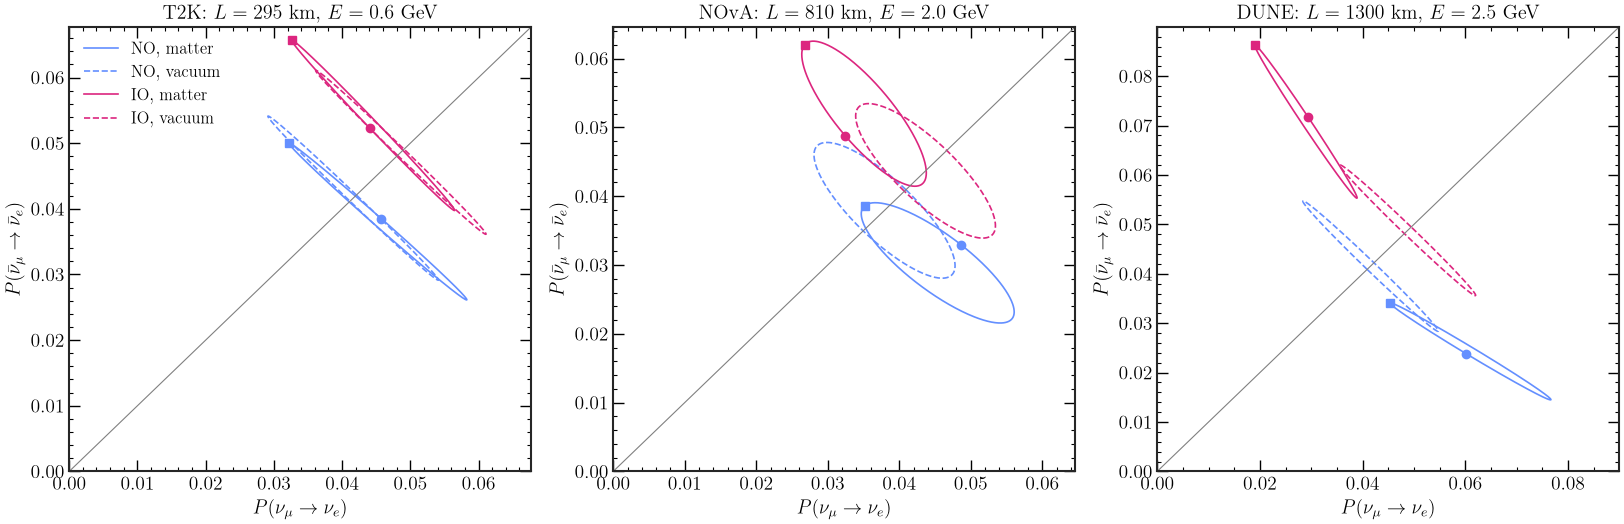

In [ ]:
deltas = np.linspace(0, 360, 361)

fig, axes = plt.subplots(1, len(COMPARE), figsize=(5.5 * len(COMPARE), 5.5), squeeze=False)
for ax, name in zip(axes[0], COMPARE):
    cfg = get_experiment(name)
    for i, ordering in enumerate(["NO", "IO"]):
        for matter, ls in [(True, "-"), (False, "--")]:
            p_nu, p_nub = [], []
            for d in deltas:
                nu  = NeutrinoOscillator.from_experiment(name, ordering, delta_cp=d, antineutrino=False)
                nub = NeutrinoOscillator.from_experiment(name, ordering, delta_cp=d, antineutrino=True)
                p_nu.append(nu.probability("mu", "e", E=cfg["E_peak"], matter=matter))
                p_nub.append(nub.probability("mu", "e", E=cfg["E_peak"], matter=matter))
            ax.plot(p_nu, p_nub, color=c[i], ls=ls,
                    label=f"{ordering}, {'matter' if matter else 'vacuum'}")
            if matter:   # mark delta = 0, 90 deg
                ax.plot(p_nu[0],  p_nub[0],  "o", color=c[i])
                ax.plot(p_nu[90], p_nub[90], "s", color=c[i])
    lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, color="grey", lw=0.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(label("mu", "e"))
    ax.set_ylabel(label("mu", "e", anti=True))
    ax.set_title(rf"{name}: $L = {cfg['baseline']:g}$ km, $E = {cfg['E_peak']}$ GeV")
axes[0, 0].legend(loc="upper left")
plt.tight_layout()
plt.show()

### 4c. Disappearance channels: (almost) blind to $\delta_{CP}$

Now the survival probabilities $P(\nu_\mu\to\nu_\mu)$ and $P(\nu_e\to\nu_e)$, in vacuum (left)
and in matter (right), for the same four values of $\delta_{CP}$.

* **CP violation needs appearance.** CPT invariance gives $P(\nu_\alpha\to\nu_\alpha) = P(\bar\nu_\alpha\to\bar\nu_\alpha)$
  in vacuum, so the CP-odd term $\propto J\sin\delta_{CP}$ cancels in every survival channel.
* **$P_{ee}$ does not depend on $\delta_{CP}$ at all**, in vacuum *and* in constant-density matter.
  $\delta_{CP}$ (like $\theta_{23}$) can be rotated into the $\mu$–$\tau$ sector, and that rotation
  commutes with the matter potential, which only acts on $\nu_e$.
* **$P_{\mu\mu}$** keeps only a small CP-even $\cos\delta_{CP}$ term, suppressed by $s_{13}$ and
  $\Delta m^2_{21}/\Delta m^2_{31}$: it is the same for $\nu$ and $\bar\nu$, so it cannot reveal CP violation.

The curves are on top of each other, so the second figure shows the **spread**
$\max_{\delta} P - \min_{\delta} P$ over $\delta_{CP}\in[0, 2\pi)$, compared with the appearance channel:
in absolute terms (left) and relative to the average probability (right). The relative spread is
what matters for an experiment: for $P_{\mu\mu}$ it is typically $1$–$10\%$, growing to $\sim 20\%$ only
near the oscillation dip, where $P_{\mu\mu}\to 0$ and very few events survive; for $P_{\mu e}$ it is
$\gtrsim 40\%$ everywhere. Note that the flux peak sits on the $P_{\mu\mu}$ dip, so the number printed
at $E_\mathrm{peak}$ is the *worst* case for $P_{\mu\mu}$.

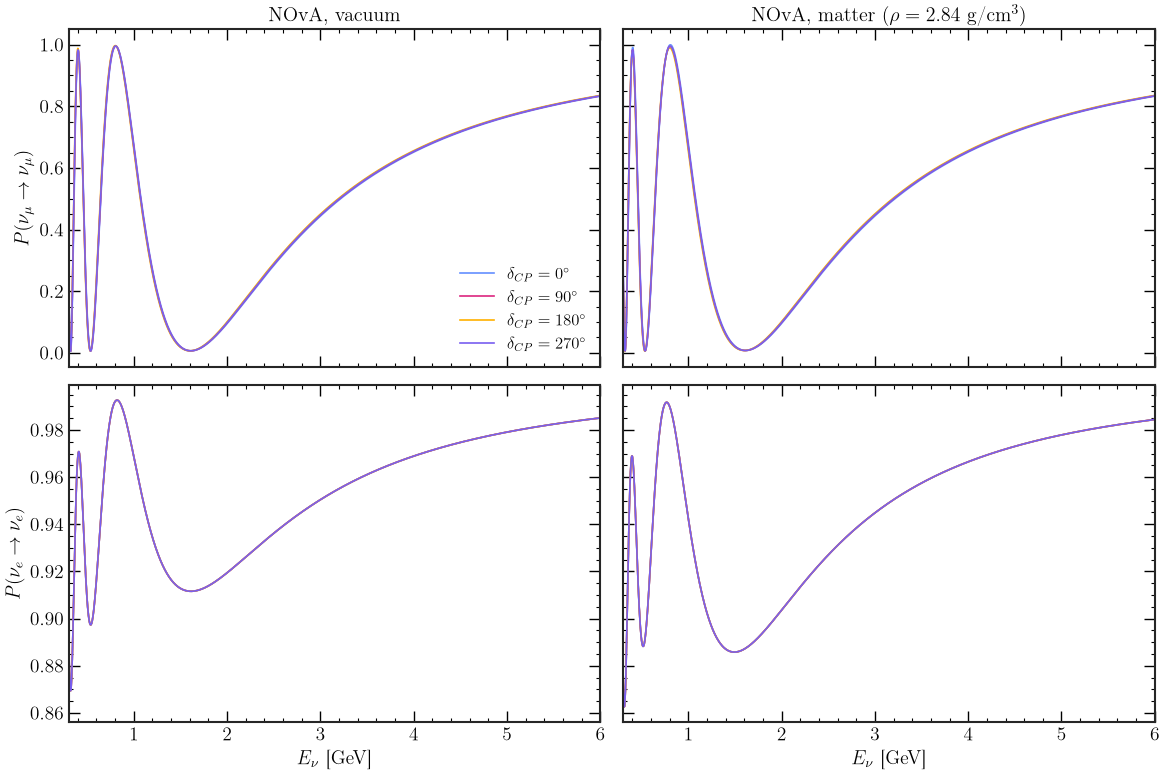

In [ ]:
osc = NeutrinoOscillator.from_experiment(EXPERIMENT, n_energy=N_ENERGY)
E = osc.energy
anti = osc.antineutrino
disappearance = [("mu", "mu"), ("e", "e")]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey="row")
for i, d in enumerate([0, 90, 180, 270]):
    osc.set_params(delta_cp=d)
    for row, (a, b) in enumerate(disappearance):
        axes[row, 0].plot(E * E_scale, osc.vacuum(a, b), color=c[i],
                          label=rf"$\delta_{{CP}} = {d}^\circ$")
        axes[row, 1].plot(E * E_scale, osc.matter(a, b), color=c[i])
for row, (a, b) in enumerate(disappearance):
    axes[row, 0].set_ylabel(label(a, b, anti))
axes[0, 0].set_title(f"{exp['name']}, vacuum")
axes[0, 1].set_title(rf"{exp['name']}, matter ($\rho = {exp['rho']}$ g/cm$^3$)")
for ax in axes[-1]:
    ax.set_xlabel(E_label)
    ax.set_xlim(E[0] * E_scale, E[-1] * E_scale)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

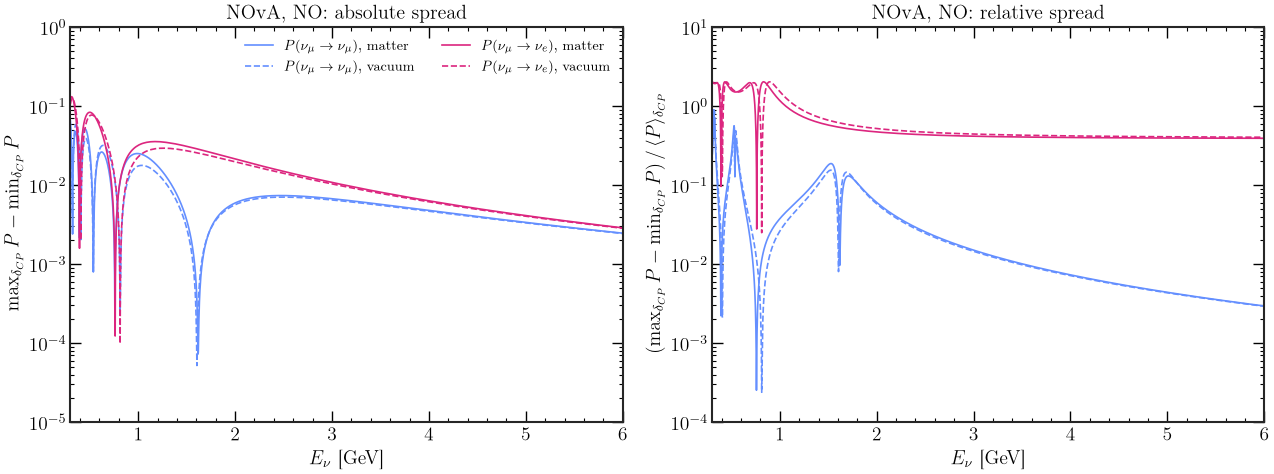

P_ee spread: vacuum 2.2e-16, matter 0.0e+00  (zero up to rounding)
At E_peak = 2.0 GeV (matter), relative spread: P_mumu 6.0%, P_mue 47.0%


In [ ]:
# Spread over delta_CP of each channel: max_delta P - min_delta P
deltas = np.linspace(0, 360, 73)
channels = [("mu", "mu"), ("mu", "e")]   # P_ee spread is exactly 0, printed below

spread, mean = {}, {}
for matter in [False, True]:
    P = []
    for d in deltas:
        osc.set_params(delta_cp=d)
        P.append(osc.probability(E=E, matter=matter))       # (3, 3, n_E)
    P = np.array(P)                                          # (n_delta, 3, 3, n_E)
    spread[matter] = P.max(axis=0) - P.min(axis=0)           # (3, 3, n_E)
    mean[matter] = P.mean(axis=0)
osc.reset()

# left: absolute spread, right: spread relative to the average probability
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for i, (a, b) in enumerate(channels):
    ia, ib = {"e": 0, "mu": 1}[a], {"e": 0, "mu": 1}[b]
    for matter, ls in [(True, "-"), (False, "--")]:
        lab = label(a, b, anti) + (", matter" if matter else ", vacuum")
        axes[0].plot(E * E_scale, np.clip(spread[matter][ia, ib], 1e-12, None),
                     color=c[i], ls=ls, label=lab)
        axes[1].plot(E * E_scale, spread[matter][ia, ib] / mean[matter][ia, ib],
                     color=c[i], ls=ls, label=lab)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-5, 1)
axes[0].set_ylabel(r"$\max_{\delta_{CP}} P - \min_{\delta_{CP}} P$")
axes[1].set_yscale("log")
axes[1].set_ylim(1e-4, 10)
axes[1].set_ylabel(r"$(\max_{\delta_{CP}} P - \min_{\delta_{CP}} P)\,/\,\langle P\rangle_{\delta_{CP}}$")
for ax in axes:
    ax.set_xlabel(E_label)
    ax.set_xlim(E[0] * E_scale, E[-1] * E_scale)
axes[0].set_title(rf"{exp['name']}, NO: absolute spread")
axes[1].set_title(rf"{exp['name']}, NO: relative spread")
axes[0].legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

print(f"P_ee spread: vacuum {spread[False][0, 0].max():.1e}, matter {spread[True][0, 0].max():.1e}  (zero up to rounding)")
k = np.argmin(np.abs(E - exp["E_peak"]))
print(f"At E_peak = {exp['E_peak']} GeV (matter), relative spread: "
      f"P_mumu {spread[True][1, 1, k] / mean[True][1, 1, k]:.1%}, "
      f"P_mue {spread[True][1, 0, k] / mean[True][1, 0, k]:.1%}")

## 5. The matter resonance: changing the density

The matter potential is $A = 2\sqrt2\,G_F N_e E \simeq 1.53\times10^{-4}\,
Y_e\,\rho\,[\mathrm{g/cm^3}]\,E\,[\mathrm{GeV}]$ eV$^2$.
When $A \approx \Delta m^2_{31}\cos2\theta_{13}$ the effective $\theta_{13}$
becomes maximal (MSW resonance): for $\rho \sim 3$–$5$ g/cm$^3$ this happens at
$E\sim 5$–$10$ GeV. Here we use a long baseline (not one of the experiments) to see it clearly.

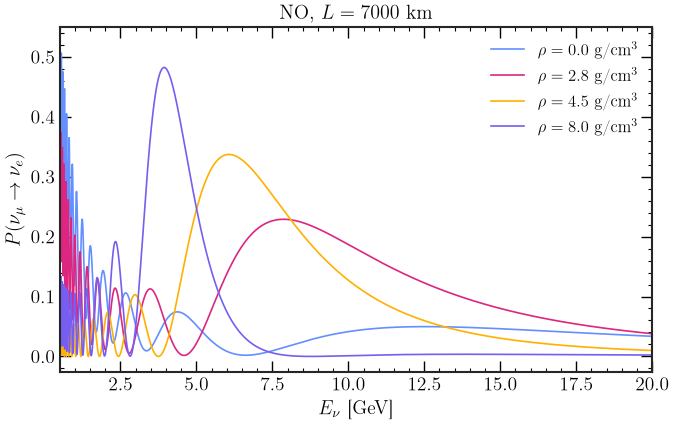

In [ ]:
E = np.linspace(0.5, 20, 3000)
L = 7000   # km

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, rho in enumerate([0.0, 2.8, 4.5, 8.0]):
    o = NeutrinoOscillator("NO", baseline=L, rho=rho)
    ax.plot(E, o.matter("mu", "e", E), color=c[i], label=rf"$\rho = {rho}$ g/cm$^3$")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(label("mu", "e"))
ax.set_title(rf"NO, $L = {L}$ km")
ax.set_xlim(E[0], E[-1])
ax.legend()
plt.tight_layout()
plt.show()

## 6. Reactor antineutrinos (JUNO)

Reactor experiments measure the survival $P(\bar\nu_e\to\bar\nu_e)$ at MeV energies.
The package works in GeV; the `JUNO` configuration already stores energies in GeV.

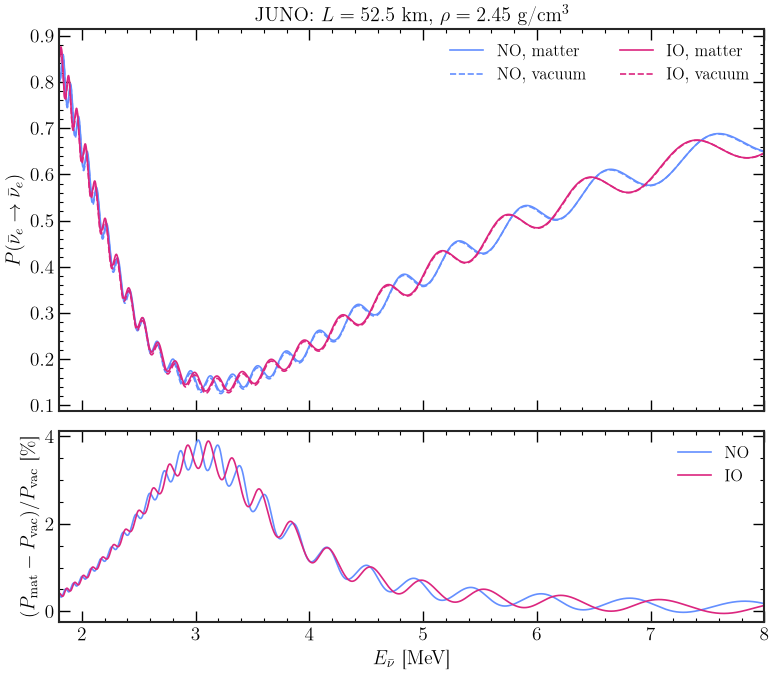

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                               gridspec_kw=dict(height_ratios=[2, 1]))
for i, ordering in enumerate(["NO", "IO"]):
    o = NeutrinoOscillator.from_experiment("JUNO", ordering=ordering, n_energy=3000)
    E_MeV = o.energy * 1e3
    Pm = o.matter("e", "e")
    Pv = o.vacuum("e", "e")
    ax1.plot(E_MeV, Pm, color=c[i], label=f"{ordering}, matter")
    ax1.plot(E_MeV, Pv, color=c[i], ls="--", label=f"{ordering}, vacuum")
    ax2.plot(E_MeV, 100 * (Pm - Pv) / Pv, color=c[i], label=ordering)
juno = get_experiment("JUNO")
ax1.set_ylabel(label("e", "e", anti=True))
ax1.set_title(rf"JUNO: $L = {juno['baseline']}$ km, $\rho = {juno['rho']}$ g/cm$^3$")
ax1.legend(ncol=2)
ax2.set_xlabel(r"$E_{\bar\nu}$ [MeV]")
ax2.set_ylabel(r"$(P_\mathrm{mat} - P_\mathrm{vac})/P_\mathrm{vac}$ [$\%$]")
ax2.set_xlim(E_MeV[0], E_MeV[-1])
ax2.legend()
plt.tight_layout()
plt.show()

## 7. Validation: NuFast vs exact numerical solution

`method="exact"` diagonalises the full Hamiltonian numerically for every energy.
It is much slower, but it is a great way to check the NuFast result.

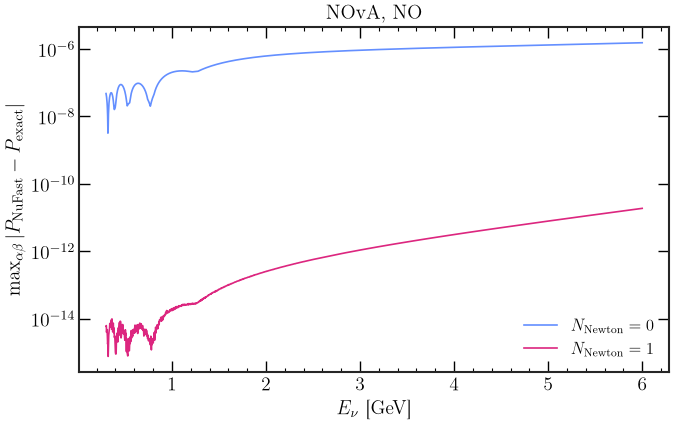

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, n in enumerate([0, 1]):
    o = NeutrinoOscillator.from_experiment(EXPERIMENT, N_Newton=n, n_energy=N_ENERGY)
    diff = np.abs(o.matter() - o.matter(method="exact")).max(axis=(0, 1))
    ax.plot(o.energy * E_scale, diff, color=c[i], label=rf"$N_\mathrm{{Newton}} = {n}$")
ax.set_yscale("log")
ax.set_xlabel(E_label)
ax.set_ylabel(r"max$_{\alpha\beta}\,|P_\mathrm{NuFast} - P_\mathrm{exact}|$")
ax.set_title(rf"{exp['name']}, NO")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Speed comparison
o = NeutrinoOscillator.from_experiment(EXPERIMENT, n_energy=100_000)
%timeit o.matter()
%timeit o.matter(method="exact")

3.42 ms ± 223 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
140 ms ± 760 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
